In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter

# Import data and split into labeled, unlabeled and test

In [29]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# -------- 1. Paths --------
BASE_DIR = "Reduced MNIST Data"
TRAIN_DIR = os.path.join(BASE_DIR, "Reduced Training data")
TEST_DIR = os.path.join(BASE_DIR, "Reduced Testing data")


# -------- 2. Load images from folder structure --------
def load_mnist_from_folders(root_dir):
    X = []
    y = []

    for label_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, label_name)

        if not os.path.isdir(class_dir):
            continue

        label = int(label_name)

        for filename in sorted(os.listdir(class_dir)):
            file_path = os.path.join(class_dir, filename)

            if not os.path.isfile(file_path):
                continue

            try:
                img = Image.open(file_path).convert("L")
                img = np.array(img, dtype=np.float32)

                if img.shape != (28, 28):
                    raise ValueError(f"Unexpected image shape {img.shape} in {file_path}")

                img = img / 255.0
                img = img.flatten()   # (28, 28) -> (784,)

                X.append(img)
                y.append(label)

            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y

# -------- 3. Load full training and testing data --------
X_train_full, y_train_full = load_mnist_from_folders(TRAIN_DIR)
X_test, y_test = load_mnist_from_folders(TEST_DIR)

print("Full training set:", X_train_full.shape, y_train_full.shape)
print("Test set:", X_test.shape, y_test.shape)


# -------- 4. Split training set into labeled + unlabeled pool --------
n_initial_labeled = 100
# VARIER N_INITIAL_LABELED FOR AT SE HVORDAN FORSKELLIGE START LABEL SET PÅVIRKER UNCERTAINTY SAMPLING PERFORMANCE
SEED = 42

X_labeled_init, X_unlabeled_init, y_labeled_init, y_unlabeled_init = train_test_split(
    X_train_full,
    y_train_full,
    train_size=n_initial_labeled,
    stratify=y_train_full,
    random_state=SEED
)

print("Initial labeled set:", X_labeled_init.shape, y_labeled_init.shape)
print("Unlabeled pool:", X_unlabeled_init.shape, y_unlabeled_init.shape)
print("Fixed test set:", X_test.shape, y_test.shape)


Full training set: (10000, 784) (10000,)
Test set: (2000, 784) (2000,)
Initial labeled set: (100, 784) (100,)
Unlabeled pool: (9900, 784) (9900,)
Fixed test set: (2000, 784) (2000,)


# The Three Uncertainty Function (Least confidence, margin, entropy)

In [30]:
def compute_uncertainty(probs, method="least_confidence"):
    """
    probs: shape (n_samples, n_classes)
    returns: uncertainty scores of shape (n_samples,)
    Higher score = more uncertain
    """
    if method == "least_confidence":
        return 1 - np.max(probs, axis=1)

    elif method == "entropy":
        eps = 1e-12
        return -np.sum(probs * np.log(probs + eps), axis=1)

    elif method == "margin":
        sorted_probs = np.sort(probs, axis=1)
        top1 = sorted_probs[:, -1]
        top2 = sorted_probs[:, -2]
        margin = top1 - top2
        return -margin

    else:
        raise ValueError(f"Unknown method: {method}")

# Active Learning Function

In [31]:
def run_active_learning(
    X_labeled_init,
    y_labeled_init,
    X_unlabeled_init,
    y_unlabeled_init,
    X_test,
    y_test,
    strategy="random",
    num_rounds=50,
    random_state=SEED
):
    X_labeled = X_labeled_init.copy()
    y_labeled = y_labeled_init.copy()
    X_unlabeled = X_unlabeled_init.copy()
    y_unlabeled = y_unlabeled_init.copy()

    rng = np.random.default_rng(random_state)

    accuracies = []
    labeled_sizes = []

    for step in range(num_rounds):
        model = LogisticRegression(max_iter=1000, C=1.0)
        model.fit(X_labeled, y_labeled)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        accuracies.append(acc)
        labeled_sizes.append(len(X_labeled))
        
        print(f"[{strategy}] Step {step}: labeled={len(X_labeled)}, acc={acc:.4f}")

        if len(X_unlabeled) == 0:
            break

        if strategy == "random":
            query_index = rng.integers(len(X_unlabeled))

        else:
            probs = model.predict_proba(X_unlabeled)
            uncertainty = compute_uncertainty(probs, method=strategy)
            query_index = np.argmax(uncertainty)

        X_query = X_unlabeled[query_index:query_index+1]
        y_query = y_unlabeled[query_index:query_index+1]

        X_labeled = np.concatenate([X_labeled, X_query], axis=0)
        y_labeled = np.concatenate([y_labeled, y_query], axis=0)

        X_unlabeled = np.delete(X_unlabeled, query_index, axis=0)
        y_unlabeled = np.delete(y_unlabeled, query_index, axis=0)

    return labeled_sizes, accuracies

# Køre de 3 uncertainty samplings og random sampling

In [32]:
strategies = ["random", "least_confidence", "entropy", "margin"]
results = {}

for strategy in strategies:
    labeled_sizes, accuracies = run_active_learning(
        X_labeled_init,
        y_labeled_init,
        X_unlabeled_init,
        y_unlabeled_init,
        X_test,
        y_test,
        strategy=strategy,
        num_rounds=50,
        random_state=SEED
    )
# VARIER NUM_ROUNDS FOR AT SE HVORDAN ANTALLET AF ADDED DATA TIL LABEL SET PÅVIRKER PERFORMANCE

    results[strategy] = {
        "labeled_sizes": labeled_sizes,
        "accuracies": accuracies
    }

    print(f"Finished strategy: {strategy}")

[random] Step 0: labeled=100, acc=0.8585
[random] Step 1: labeled=101, acc=0.8585
[random] Step 2: labeled=102, acc=0.8635
[random] Step 3: labeled=103, acc=0.8660
[random] Step 4: labeled=104, acc=0.8610
[random] Step 5: labeled=105, acc=0.8615
[random] Step 6: labeled=106, acc=0.8600
[random] Step 7: labeled=107, acc=0.8625
[random] Step 8: labeled=108, acc=0.8630
[random] Step 9: labeled=109, acc=0.8630
[random] Step 10: labeled=110, acc=0.8615
[random] Step 11: labeled=111, acc=0.8615
[random] Step 12: labeled=112, acc=0.8595
[random] Step 13: labeled=113, acc=0.8575
[random] Step 14: labeled=114, acc=0.8570
[random] Step 15: labeled=115, acc=0.8580
[random] Step 16: labeled=116, acc=0.8595
[random] Step 17: labeled=117, acc=0.8595
[random] Step 18: labeled=118, acc=0.8590
[random] Step 19: labeled=119, acc=0.8610
[random] Step 20: labeled=120, acc=0.8615
[random] Step 21: labeled=121, acc=0.8610
[random] Step 22: labeled=122, acc=0.8655
[random] Step 23: labeled=123, acc=0.8620
[r

# Plot performance

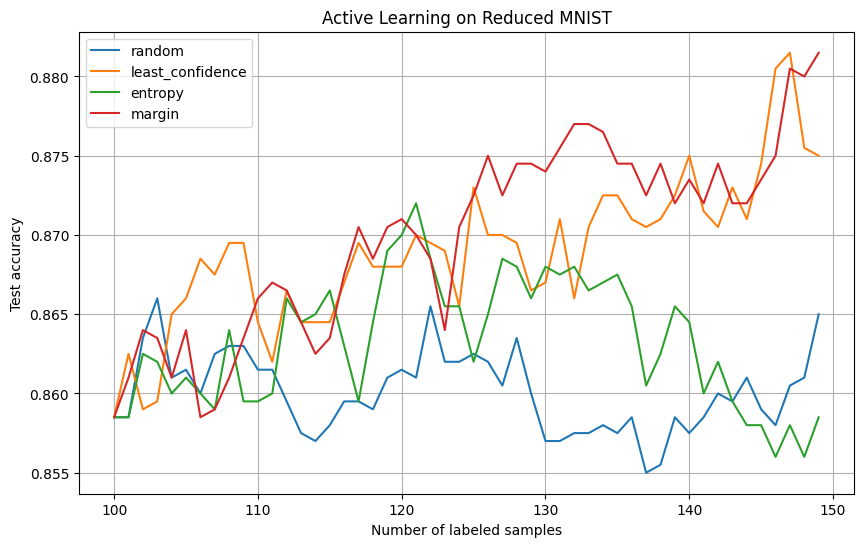

In [33]:
plt.figure(figsize=(10, 6))

for strategy, res in results.items():
    plt.plot(res["labeled_sizes"], res["accuracies"], label=strategy)

plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active Learning on Reduced MNIST")
plt.legend()
plt.grid(True)
plt.show()